# Hyperparameter Search (Canonical Self-Play)

Every notebook so far used the same hyperparameters: α=0.1, γ=0.9 and ε multiplied by 0.9995 per game.
Here we run a **grid search** to see how much each of them matters for canonical self-play:

| Hyperparameter | Symbol | Role |
|---|---|---|
| **Learning rate** | α | How far each update moves a Q-value |
| **Discount factor** | γ | How much future value counts compared to the immediate reward |
| **Epsilon decay** | ε_decay | How quickly the agent shifts from exploration to exploitation |

Each configuration is trained and then evaluated against two opponents:

- **Minimax**: the loss rate measures the distance from perfect play (the main criterion).
- **Random**: the win rate measures how well the agent exploits mistakes.

A single training run can be lucky or unlucky, so each configuration is trained with several seeds and
the results are averaged.

## Setup

The reusable code lives in the `core` package, one folder up (`04_qlearning/core/`). We add that folder
to Python's import path so that `from core... import ...` works from this notebook. A fixed random seed
makes the results reproducible.

In [1]:
import sys
import random
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
random.seed(42)

## Training and Evaluation Function

In [2]:
from statistics import mean

from core.environment import TicTacToeEnvironment
from core.agents.q_learning_agent import QLearningAgent
from core.agents.random_agent import RandomAgent
from core.agents.minimax_agent import MinimaxAgent
from core.training import play_game, evaluate_agent


def train_canonical(learning_rate: float, discount_factor: float, epsilon_decay: float,
                    n_episodes: int, min_epsilon: float = 0.05) -> QLearningAgent:
    """Train with canonical self-play and return the X agent (it shares its Q-table with O)."""
    shared_q_table = {}
    agent_x, agent_o = (QLearningAgent(symbol=symbol, q_table=shared_q_table, canonical_state=True,
                                       learning_rate=learning_rate, discount_factor=discount_factor, epsilon=1.0)
                        for symbol in ('X', 'O'))
    env = TicTacToeEnvironment()
    epsilon = 1.0
    for _ in range(n_episodes):
        epsilon = max(min_epsilon, epsilon * epsilon_decay)
        agent_x.set_epsilon(epsilon)
        agent_o.set_epsilon(epsilon)
        play_game(agent_x, agent_o, env, x_starts=random.choice([True, False]))
    return agent_x


def train_and_evaluate(learning_rate: float, discount_factor: float, epsilon_decay: float,
                       n_episodes: int, seeds: range) -> dict[str, float]:
    """Average evaluation over one training run per seed."""
    evaluations = []
    for seed in seeds:
        random.seed(seed)
        agent = train_canonical(learning_rate, discount_factor, epsilon_decay, n_episodes)
        evaluations.append((evaluate_agent(agent, MinimaxAgent('O'), n_games=200),
                            evaluate_agent(agent, RandomAgent('O'), n_games=500)))
    return {
        'α': learning_rate,
        'γ': discount_factor,
        'ε_decay': epsilon_decay,
        'Loss % vs Minimax': 100 * mean(m['loss_rate'] for m, _ in evaluations),
        'Win % vs Random': 100 * mean(r['win_rate'] for _, r in evaluations),
        'Loss % vs Random': 100 * mean(r['loss_rate'] for _, r in evaluations),
    }

## Search Space

Three values for each hyperparameter give **3 × 3 × 3 = 27** configurations.

| Parameter | Values | Range covered |
|---|---|---|
| α | 0.05, 0.1, 0.3 | conservative → aggressive updates |
| γ | 0.5, 0.9, 0.99 | short-sighted → far-sighted |
| ε_decay | 0.999, 0.9995, 0.9999 | ε reaches 0.05 after ~3,000 / ~6,000 / ~30,000 games |

With 0.9999, ε is still around 0.14 at the end of 20,000 episodes: the agent keeps exploring a lot.

In [3]:
from itertools import product

learning_rates = [0.05, 0.1, 0.3]
discount_factors = [0.5, 0.9, 0.99]
epsilon_decays = [0.999, 0.9995, 0.9999]

N_EPISODES = 20000
SEEDS = range(3)

configurations = list(product(learning_rates, discount_factors, epsilon_decays))
print(f"{len(configurations)} configurations × {len(SEEDS)} seeds × {N_EPISODES} episodes")

27 configurations × 3 seeds × 20000 episodes


## Grid Search

This cell takes a few minutes.

In [4]:
import pandas as pd

results = pd.DataFrame([train_and_evaluate(lr, gamma, decay, N_EPISODES, SEEDS)
                        for lr, gamma, decay in configurations])
ranking = results.sort_values(['Loss % vs Minimax', 'Loss % vs Random', 'Win % vs Random'],
                              ascending=[True, True, False]).reset_index(drop=True)
METRICS = ['Loss % vs Minimax', 'Win % vs Random', 'Loss % vs Random']
ranking.round({metric: 1 for metric in METRICS})

,α,γ,ε_decay,Loss % vs Minimax,Win % vs Random,Loss % vs Random
0,0.10,0.90,0.9995,0.0,95.3,0.0
1,0.30,0.99,0.9995,0.0,92.7,0.0
2,0.30,0.50,0.9990,0.0,92.1,0.0
3,0.30,0.90,0.9995,0.0,91.9,0.0
4,0.10,0.50,0.9990,0.0,90.4,0.0
5,0.30,0.50,0.9995,0.0,90.3,0.0
6,0.30,0.99,0.9990,0.0,87.0,0.1
7,0.10,0.99,0.9995,0.0,91.3,0.2
8,0.30,0.90,0.9990,0.0,85.7,0.2
9,0.05,0.99,0.9995,0.0,91.9,0.3


## Best and Worst Configurations

In [5]:
ranking.iloc[[0, -1]].round({metric: 1 for metric in METRICS}).set_axis(['best', 'worst'])

,α,γ,ε_decay,Loss % vs Minimax,Win % vs Random,Loss % vs Random
best,0.1,0.90,0.9995,0.0,95.3,0.0
worst,0.3,0.99,0.9999,9.8,92.2,0.5


## Effect of Each Hyperparameter

We average the metrics over all the configurations that share each value. A parameter that matters shows
a clear trend.

In [6]:
pd.concat({parameter: results.groupby(parameter)[METRICS].mean() for parameter in ['α', 'γ', 'ε_decay']}).round(1)

Loss % vs Minimax  Win % vs Random  Loss % vs Random
α       0.0500                3.5             92.2               1.1
        0.1000                1.2             91.4               1.0
        0.3000                1.1             90.5               0.3
γ       0.5000                1.6             91.9               0.8
        0.9000                2.3             91.2               0.8
        0.9900                1.9             91.0               0.8
ε_decay 0.9990                0.9             90.4               0.1
        0.9995                1.1             92.2               0.2
        0.9999                3.8             91.5               2.1

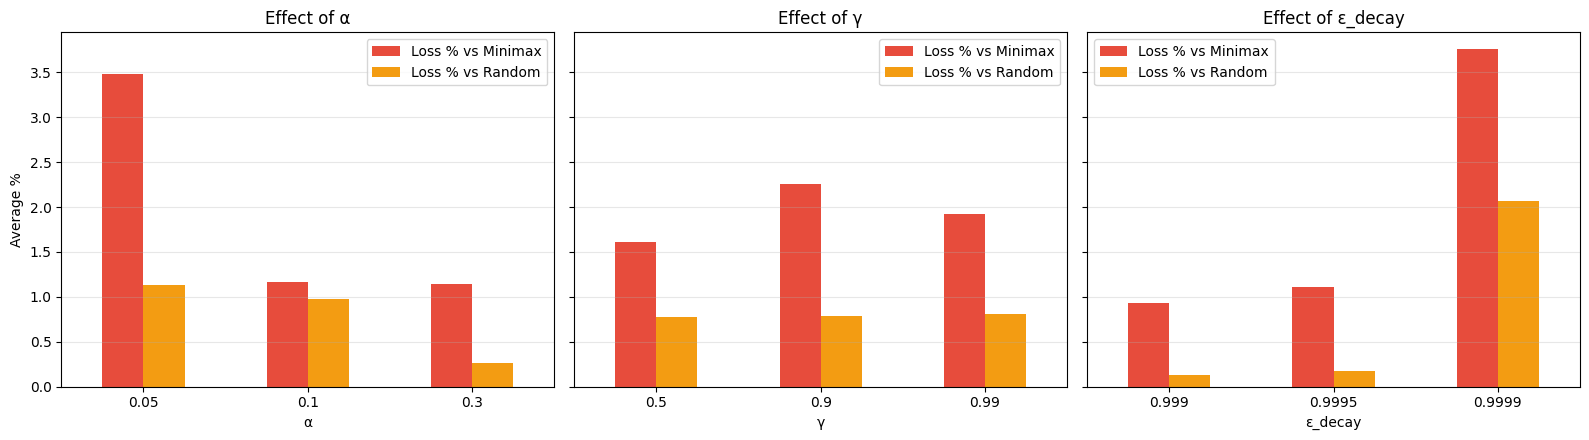

In [7]:
import matplotlib.pyplot as plt

metrics = ['Loss % vs Minimax', 'Loss % vs Random']
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for axis, parameter in zip(axes, ['α', 'γ', 'ε_decay']):
    results.groupby(parameter)[metrics].mean().plot(kind='bar', ax=axis, rot=0, color=['#e74c3c', '#f39c12'])
    axis.set_title(f"Effect of {parameter}")
    axis.set_ylabel("Average %")
    axis.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Interaction Between α and γ

The heatmap shows the loss rate against Minimax for each (α, γ) pair, averaged over ε_decay.

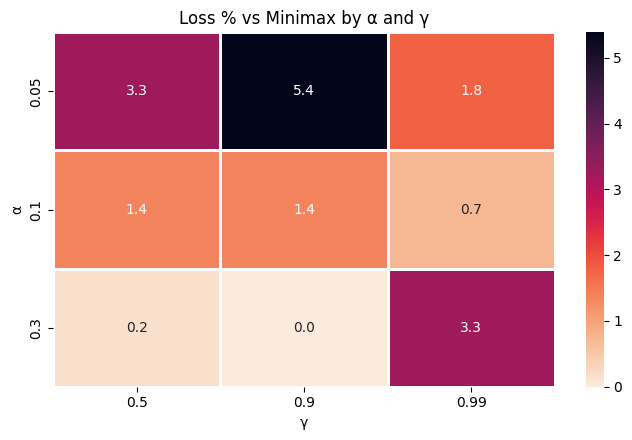

In [8]:
import seaborn as sns

pivot = results.pivot_table(values='Loss % vs Minimax', index='α', columns='γ', aggfunc='mean')
plt.figure(figsize=(7, 4.5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='rocket_r', linewidths=1, linecolor='white')
plt.title('Loss % vs Minimax by α and γ')
plt.tight_layout()
plt.show()

## Conclusions

- **Canonical self-play is robust.** 11 of the 27 configurations never lost against Minimax (0.0% averaged over 3 seeds), and even the worst one loses under 10%. The default configuration used in every notebook (α=0.1, γ=0.9, ε_decay=0.9995) ranks first.
- **ε_decay has the clearest effect.** With 0.9999, ε is still about 0.14 after 20,000 episodes (0.9999²⁰⁰⁰⁰ ≈ e⁻² ≈ 0.135). The agent spends much of its budget exploring, and training games are full of random moves. The average loss rate is 3.8% against Minimax and 2.1% against Random, compared with about 1% and 0.1-0.2% for faster decays.
- **α=0.05 is too slow for this budget** (3.5% loss against Minimax). 0.1 and 0.3 perform about the same.
- **γ shows no clear trend between 0.5 and 0.99** (1.6%, 2.3% and 1.9%, within the noise of 3 seeds). This does not mean γ is irrelevant: notebook 02 showed that γ=0 loses about 68% against Minimax. A game of tic-tac-toe lasts at most 5 moves per player, so any γ clearly above 0 lets the final result reach the first moves. What the agent needs is the right *ordering* of its Q-values, not their exact size.

**Limitations.** With 3 seeds, 200 games against Minimax and 500 against Random, differences of 1-2 points are not significant. Many configurations also reach 0% against Minimax, so this criterion cannot tell them apart: the benchmark is *saturated*.

**Exercise:** repeat the search with 5,000 episodes per run, before most configurations converge. Which hyperparameters make the agent learn *fastest*?